# 01 - Data Exploration
## Consumer Complaint Text Analytics

**Team Members:** Yanxin Li, Yasmine Zhao, Ellie Ha, Maral Vahedi  
**Course:** INSY 669 - Text Analytics  
**Date:** January 2026

---

### Objectives
1. Load and examine the raw consumer complaint data
2. Understand the data structure and content
3. Perform initial data quality checks
4. Explore the complaint narratives
5. Generate summary statistics

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add src to path
sys.path.append('../src')

# Import custom modules
from data_processing import DataLoader, DataCleaner

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [4]:
# Initialize data loader
loader = DataLoader(config_path='../config.yaml')

# Load raw data
# Update the path to your actual CSV file
df = loader.load_raw_data('../data/raw/consumer_complaints.csv')

print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

INFO:data_processing.data_loader:Loading data from ../data/raw/consumer_complaints.csv
INFO:data_processing.data_loader:Successfully loaded 1046669 records


Data loaded: 1046669 rows, 18 columns


## 2. Initial Data Inspection

In [5]:
# Display first few rows
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,12/28/25,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt was result of identity theft,"I do not recognize the aforementioned accounts, collections, or hard inquiries as reported. The ...",Company has responded to the consumer and the CFPB and chooses not to provide a public response,"I.C. System, Inc.",IN,46201,NaN,Consent provided,Web,12/28/25,Closed with explanation,Yes,NaN,18327208.0
1,09/26/25,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,"I am writing pursuant to the Fair Credit Reporting Act ( FCRA ), particularly Section 605B [ 15 ...",NaN,"EQUIFAX, INC.",LA,71457,NaN,Consent provided,Web,09/26/25,Closed with non-monetary relief,Yes,NaN,16207045.0
2,03/15/25,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,I am writing to formally dispute several unauthorized transactions on my account that occurred a...,NaN,TD BANK US HOLDING COMPANY,MA,01803,NaN,Consent provided,Web,03/15/25,Closed with explanation,Yes,NaN,12493914.0
3,2005-03-25,Debt collection,Other debt,Attempts to collect debt not owed,Debt was result of identity theft,"I am sending this asking for your help to file a formal complaint against XXXX, XXXX XXXX XXXX r...",NaN,"Portfolio Recovery Associates, LLC",TX,77373,NaN,Consent provided,Web,2005-03-25,Closed with non-monetary relief,Yes,NaN,13317604.0
4,04/29/25,Credit reporting or other personal consumer reports,Credit reporting,Improper use of your report,Reporting company used your report improperly,"Upon reviewing my consumer reports, l discovered some instances of late payments on an account f...",Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NJ,08016,NaN,Consent provided,Web,04/29/25,Closed with non-monetary relief,Yes,NaN,13232751.0


In [6]:
# Column names and types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1046669 entries, 0 to 1046668
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date received                 24631 non-null  str    
 1   Product                       24631 non-null  str    
 2   Sub-product                   24631 non-null  str    
 3   Issue                         24631 non-null  str    
 4   Sub-issue                     23594 non-null  str    
 5   Consumer complaint narrative  24631 non-null  str    
 6   Company public response       13729 non-null  str    
 7   Company                       24631 non-null  str    
 8   State                         24564 non-null  str    
 9   ZIP code                      24631 non-null  str    
 10  Tags                          1478 non-null   str    
 11  Consumer consent provided?    24631 non-null  str    
 12  Submitted via                 24631 non-null  str    
 13  Date sen

In [7]:
# Summary statistics
df.describe()

,Consumer disputed?,Complaint ID
count,0.0,2.463100e+04
mean,NaN,1.574880e+07
std,NaN,1.631920e+06
min,NaN,1.158563e+07
25%,NaN,1.489737e+07
50%,NaN,1.627568e+07
75%,NaN,1.696720e+07
max,NaN,1.886385e+07


## 3. Data Quality Assessment

In [8]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})

missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Percentage
Consumer disputed?,1046669,100.000000
Tags,1045191,99.858790
Company public response,1032940,98.688315
Sub-issue,1023075,97.745801
State,1022105,97.653126
Date received,1022038,97.646725
Consumer consent provided?,1022038,97.646725
Timely response?,1022038,97.646725
Company response to consumer,1022038,97.646725
Date sent to company,1022038,97.646725


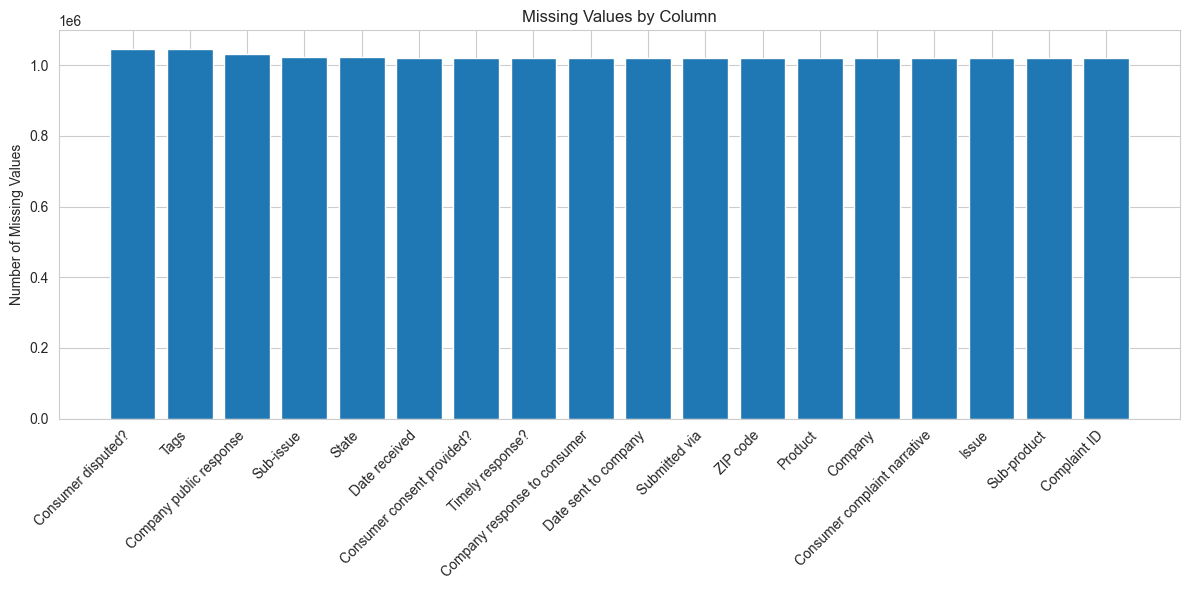

In [9]:
# Visualize missing data
plt.figure(figsize=(12, 6))
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.bar(range(len(missing_counts)), missing_counts.values)
plt.xticks(range(len(missing_counts)), missing_counts.index, rotation=45, ha='right')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.show()

## 4. Explore Complaint Narratives

In [10]:
# Extract text column (adjust column name as needed)
text_col = 'Consumer complaint narrative'

if text_col in df.columns:
    complaints = loader.get_text_column(df, text_col)
    print(f"Non-null complaint narratives: {len(complaints)}")
else:
    print(f"Column '{text_col}' not found. Available columns:")
    print(df.columns.tolist())

INFO:data_processing.data_loader:Extracted 24631 non-null text records


Non-null complaint narratives: 24631


In [11]:
# Example complaints
print("Sample Complaint Narratives:\n")
for i, text in enumerate(complaints.head(3), 1):
    print(f"Complaint {i}:")
    print(text[:500] + "..." if len(text) > 500 else text)
    print("-" * 80)

Sample Complaint Narratives:

Complaint 1:
I do not recognize the aforementioned accounts, collections, or hard inquiries as reported. The aforementioned accounts, collections, and hard inquiries appearing on my consumer credit report maintained by you were not opened, made, or initiated by me. All of the aforementioned accounts, collections, and hard inquiries are the result of identity theft and fraud.According to USC 15 1681 I have the right to dispute inaccurate and unverifiable information thats on my credit report. I disputed multi...
--------------------------------------------------------------------------------
Complaint 2:
I am writing pursuant to the Fair Credit Reporting Act ( FCRA ), particularly Section 605B [ 15 U.S. Code 1681c2 ], which mandates that consumer reporting agencies must block and remove all information resulting from identity theft within XXXX business days of receiving appropriate proof. 
I am a victim of identity theft, and fraudulent activity has been re

In [12]:
# Text length statistics
complaints_df = pd.DataFrame({'text': complaints})
complaints_df['char_count'] = complaints_df['text'].str.len()
complaints_df['word_count'] = complaints_df['text'].str.split().str.len()

print("Text Length Statistics:")
print(complaints_df[['char_count', 'word_count']].describe())

Text Length Statistics:
         char_count    word_count
count  24631.000000  24631.000000
mean    1088.975194    182.121067
std     1280.393444    211.943719
min        6.000000      1.000000
25%      394.000000     67.000000
50%      760.000000    128.000000
75%     1324.000000    223.000000
max    31271.000000   5699.000000


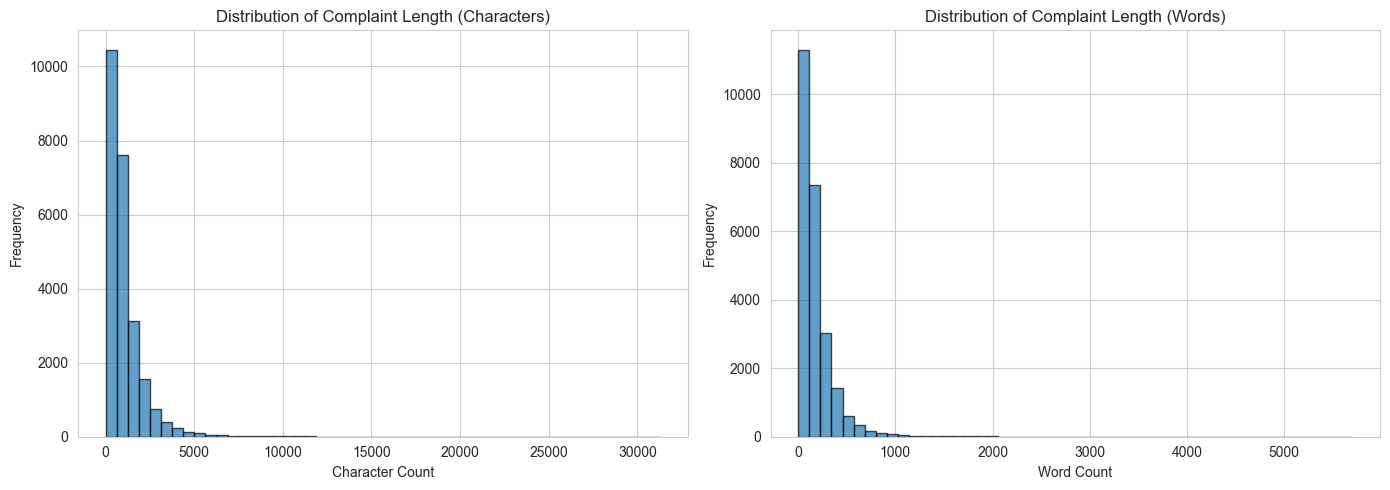

In [13]:
# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character count distribution
axes[0].hist(complaints_df['char_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Complaint Length (Characters)')

# Word count distribution
axes[1].hist(complaints_df['word_count'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Complaint Length (Words)')

plt.tight_layout()
plt.show()

## 5. Explore Structured Fields

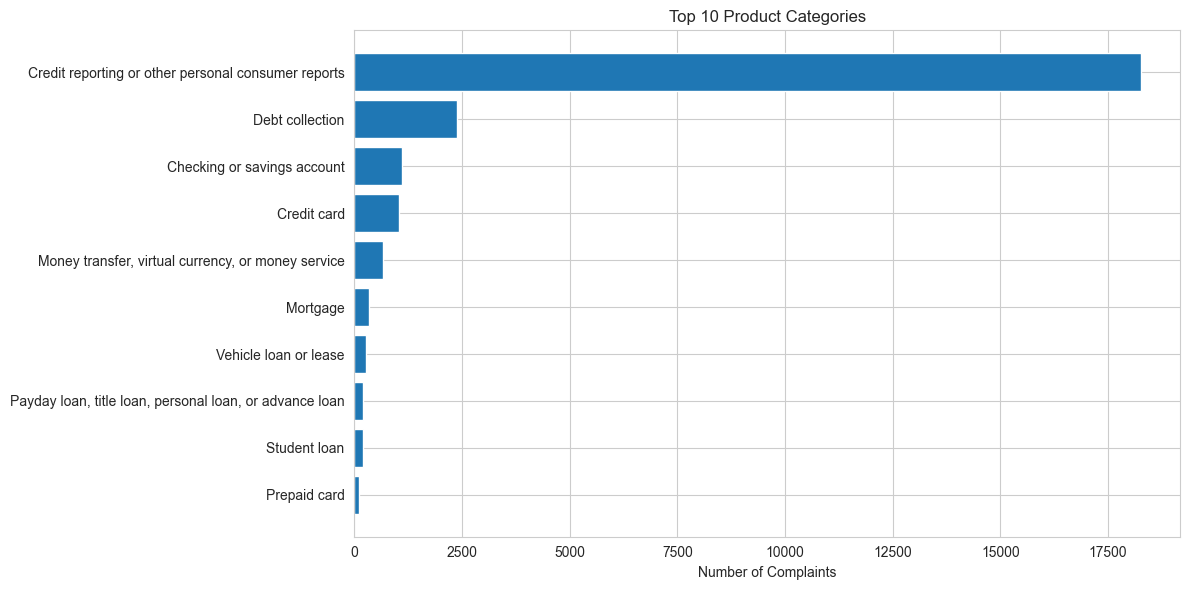

In [14]:
# Product categories
if 'Product' in df.columns:
    product_counts = df['Product'].value_counts().head(10)
    
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(product_counts)), product_counts.values)
    plt.yticks(range(len(product_counts)), product_counts.index)
    plt.xlabel('Number of Complaints')
    plt.title('Top 10 Product Categories')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

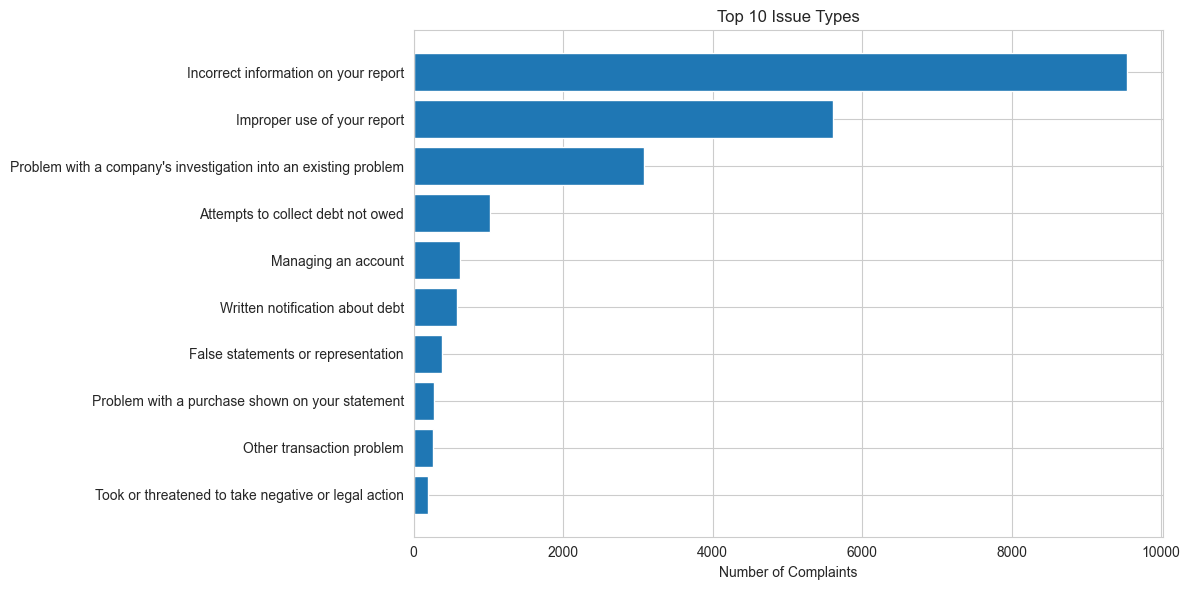

In [15]:
# Issue types
if 'Issue' in df.columns:
    issue_counts = df['Issue'].value_counts().head(10)
    
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(issue_counts)), issue_counts.values)
    plt.yticks(range(len(issue_counts)), issue_counts.index)
    plt.xlabel('Number of Complaints')
    plt.title('Top 10 Issue Types')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()